# Supplementary Figure S7: Cross-Species Validation
Assessment of mouse-human homolog mapping and validation of AD-relevant cell types.

In [1]:
%matplotlib inline
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import os
from matplotlib_venn import venn2

LEGEND_FS = 11; TICK_FS = 12; LABEL_FS = 13; TITLE_FS = 13; TEXT_FS = 12

def save_all_formats(fig, basepath, dpi=300):
    fig.savefig(f"{basepath}.pdf", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.svg", bbox_inches="tight")

BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures', exist_ok=True)

## Load homolog mapping and per-organ gene lists

In [3]:
homologs = pd.read_csv(f'{BASE}/data/gsMap_resource/homologs/mouse_human_homologs.txt', sep='\t')
mouse_genes_in_map = set(homologs['MOUSE_GENE_SYM'].dropna().unique())
human_genes_in_map = set(homologs['HUMAN_GENE_SYM'].dropna().unique())
print(f'Homolog mappings: {len(homologs)}')
print(f'Unique mouse genes in mapping: {len(mouse_genes_in_map)}')
print(f'Unique human genes in mapping: {len(human_genes_in_map)}')

# Load gene lists per organ
organ_files = sorted([f for f in os.listdir(f'{BASE}/data/st/per_organ/') if f.endswith('.h5ad') and 'CTRL1' in f])
organ_genes = {}
for fname in organ_files:
    organ_name = fname.replace('_CTRL1.h5ad', '').replace('_', ' ')
    tmp = ad.read_h5ad(f'{BASE}/data/st/per_organ/{fname}', backed='r')
    organ_genes[organ_name] = set(tmp.var_names.tolist())
    del tmp

print(f'\nOrgans loaded: {len(organ_genes)}')
for org, genes in organ_genes.items():
    mapped = genes & mouse_genes_in_map
    print(f'  {org}: {len(genes)} genes, {len(mapped)} mapped ({100*len(mapped)/len(genes):.1f}%)')

Homolog mappings: 17596
Unique mouse genes in mapping: 17596
Unique human genes in mapping: 17596



Organs loaded: 16
  Bone Marrow: 32285 genes, 16752 mapped (51.9%)
  Brain: 32285 genes, 16752 mapped (51.9%)
  Brown Fat: 32285 genes, 16752 mapped (51.9%)
  Colon: 32285 genes, 16752 mapped (51.9%)
  Heart: 32285 genes, 16752 mapped (51.9%)
  Kidney: 32285 genes, 16752 mapped (51.9%)
  Liver: 32285 genes, 16752 mapped (51.9%)
  Lung: 32285 genes, 16752 mapped (51.9%)
  Lymph Node: 32285 genes, 16752 mapped (51.9%)
  Muscle: 32285 genes, 16752 mapped (51.9%)
  Pancreas: 32285 genes, 16752 mapped (51.9%)
  Skin: 32285 genes, 16752 mapped (51.9%)
  Small Intestine: 32285 genes, 16752 mapped (51.9%)
  Spleen: 32285 genes, 16752 mapped (51.9%)
  Stomach: 32285 genes, 16752 mapped (51.9%)
  Thymus: 32285 genes, 16752 mapped (51.9%)


## Panel A: UpSet-style diagram of gene coverage across organs
Since organs share largely the same gene set, we show a Venn diagram comparing the homolog-mapped genes vs. all expressed genes for a representative subset.

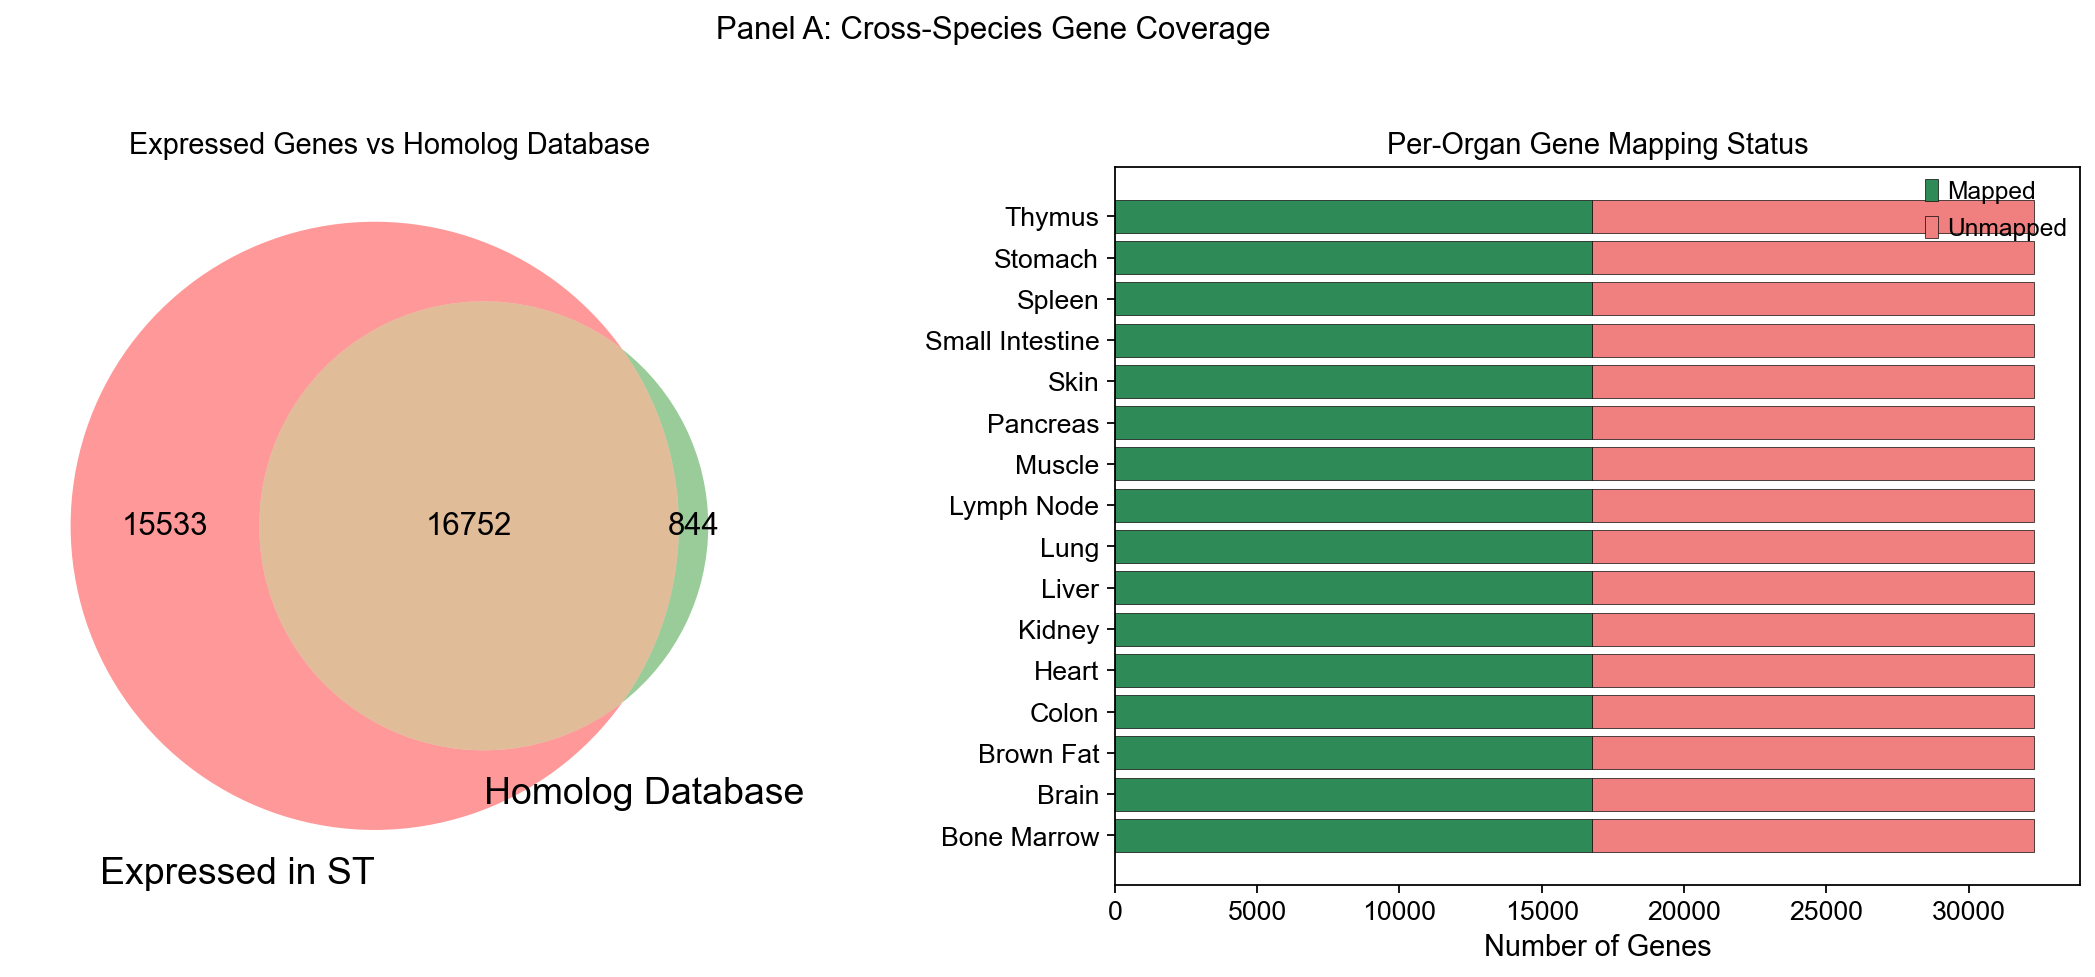

In [4]:
# Venn diagram: all expressed mouse genes vs homolog-mapped mouse genes
# Use union of all organ gene sets
all_expressed = set()
for genes in organ_genes.values():
    all_expressed |= genes

mapped_expressed = all_expressed & mouse_genes_in_map
only_expressed = all_expressed - mouse_genes_in_map
only_homolog = mouse_genes_in_map - all_expressed

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A left: Venn of all expressed vs homolog database
ax = axes[0]
try:
    v = venn2(
        [all_expressed, mouse_genes_in_map],
        set_labels=('Expressed in ST', 'Homolog Database'),
        ax=ax
    )
    ax.set_title('Expressed Genes vs Homolog Database', fontsize=TITLE_FS)
except Exception:
    # Fallback if matplotlib_venn not available
    ax.bar(['Expressed Only', 'Mapped (Overlap)', 'Homolog DB Only'],
           [len(only_expressed), len(mapped_expressed), len(only_homolog)],
           color=['steelblue', 'seagreen', 'coral'], edgecolor='k', linewidth=0.5)
    ax.set_ylabel('Number of Genes', fontsize=LABEL_FS)
    ax.set_title('Expressed Genes vs Homolog Database', fontsize=TITLE_FS)
    ax.tick_params(labelsize=TICK_FS)

# Panel A right: per-organ mapped vs unmapped stacked bar
ax = axes[1]
organs_sorted = sorted(organ_genes.keys())
mapped_counts = [len(organ_genes[o] & mouse_genes_in_map) for o in organs_sorted]
unmapped_counts = [len(organ_genes[o] - mouse_genes_in_map) for o in organs_sorted]

y_pos = np.arange(len(organs_sorted))
ax.barh(y_pos, mapped_counts, color='seagreen', edgecolor='k', linewidth=0.3, label='Mapped')
ax.barh(y_pos, unmapped_counts, left=mapped_counts, color='lightcoral', edgecolor='k', linewidth=0.3, label='Unmapped')
ax.set_yticks(y_pos)
ax.set_yticklabels(organs_sorted, fontsize=TICK_FS)
ax.set_xlabel('Number of Genes', fontsize=LABEL_FS)
ax.set_title('Per-Organ Gene Mapping Status', fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS)
ax.tick_params(axis='x', labelsize=TICK_FS)

fig.suptitle('Panel A: Cross-Species Gene Coverage', fontsize=TITLE_FS + 1, y=1.02)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S07A_gene_coverage_venn')

## Panel B: Bar chart of homolog coverage (% genes mapped) per organ

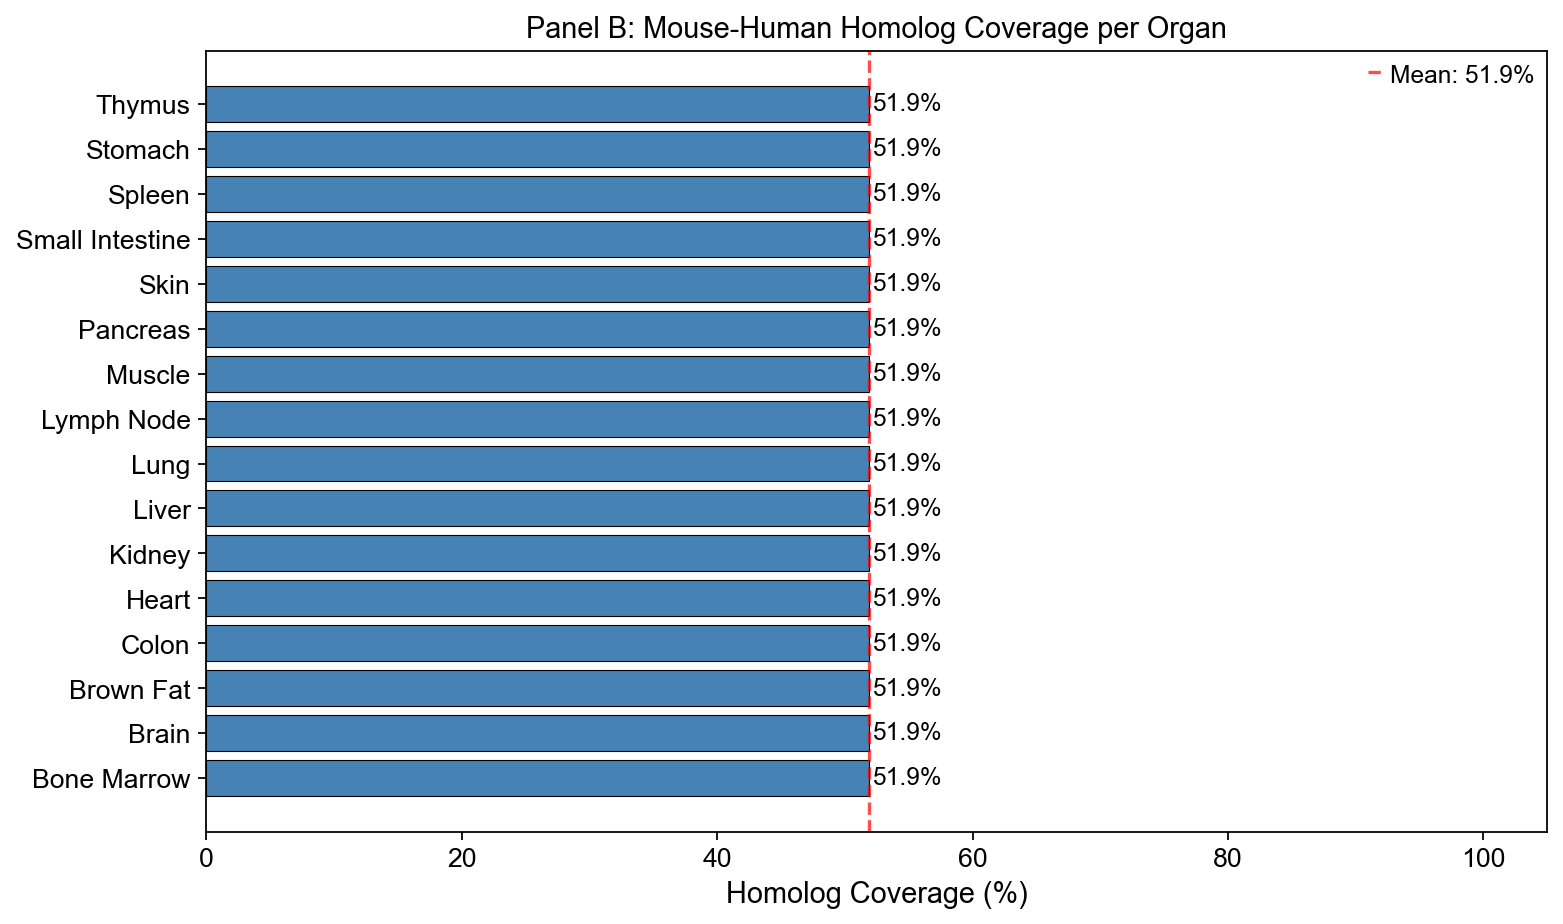

In [5]:
coverage_pct = []
for org in organs_sorted:
    genes = organ_genes[org]
    mapped = genes & mouse_genes_in_map
    coverage_pct.append(100.0 * len(mapped) / len(genes))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(organs_sorted, coverage_pct, color='steelblue', edgecolor='k', linewidth=0.5)
for bar, val in zip(bars, coverage_pct):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=TEXT_FS - 1)

ax.set_xlabel('Homolog Coverage (%)', fontsize=LABEL_FS)
ax.set_title('Panel B: Mouse-Human Homolog Coverage per Organ', fontsize=TITLE_FS)
ax.tick_params(labelsize=TICK_FS)
ax.set_xlim(0, 105)
ax.axvline(np.mean(coverage_pct), color='red', linestyle='--', alpha=0.7,
           label=f'Mean: {np.mean(coverage_pct):.1f}%')
ax.legend(fontsize=LEGEND_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S07B_homolog_coverage_bar')

## Panel C: Known AD cell types enrichment in brain subregions

In [6]:
# Known AD-relevant cell types and brain regions
# Check if brain samples are processed; if not, use available immune-related organs
available_samples = sorted([d for d in os.listdir(f'{BASE}/models/gsmap_output/')
                            if os.path.isdir(f'{BASE}/models/gsmap_output/{d}')])

# Known AD cell types from literature
ad_celltypes = {
    'Microglia': ['microglia', 'Microglia'],
    'Astrocytes': ['astrocyte', 'Astrocyte', 'astrocytes', 'Astrocytes'],
    'Oligodendrocytes': ['oligodendrocyte', 'Oligodendrocyte', 'oligodendrocytes', 'Oligodendrocytes'],
    'Neurons': ['neuron', 'Neuron', 'neurons', 'Neurons', 'neuronal', 'Neuronal'],
}

# Load Cauchy results and check for AD-relevant annotations
cauchy_dfs = []
for sname in available_samples:
    fpath = f'{BASE}/models/gsmap_output/{sname}/cauchy_combination/{sname}_AD.Cauchy.csv.gz'
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df['sample_name'] = sname
        df['organ'] = sname.rsplit('_', 1)[0].replace('_', ' ')
        df['logp_cauchy'] = -np.log10(df['p_cauchy'].clip(lower=1e-300))
        cauchy_dfs.append(df)

cauchy_all = pd.concat(cauchy_dfs, ignore_index=True)

# Check which annotations match AD-relevant cell types
def classify_celltype(annotation):
    annot_lower = annotation.lower()
    for ct, keywords in ad_celltypes.items():
        for kw in keywords:
            if kw.lower() in annot_lower:
                return ct
    return 'Other'

cauchy_all['ad_celltype'] = cauchy_all['annotation'].apply(classify_celltype)

# Show all annotations grouped by AD relevance
print('AD-relevant annotations found:')
ad_relevant = cauchy_all[cauchy_all['ad_celltype'] != 'Other']
if len(ad_relevant) > 0:
    print(ad_relevant[['annotation', 'organ', 'ad_celltype', 'p_cauchy', 'logp_cauchy']])
else:
    print('No brain-specific annotations found in processed samples.')
    print('\nAll available annotations and their enrichment:')
    print(cauchy_all[['annotation', 'organ', 'p_cauchy', 'logp_cauchy']].sort_values('p_cauchy'))

AD-relevant annotations found:
No brain-specific annotations found in processed samples.

All available annotations and their enrichment:
                        annotation       organ      p_cauchy  logp_cauchy
69                   Marginal Zone      Spleen  2.477731e-08     7.605946
72                   Marginal Zone      Spleen  3.400748e-08     7.468426
70                      White Pulp      Spleen  1.481460e-07     6.829310
50               Lymph Node Tissue  Lymph Node  5.489622e-07     6.260458
73                      White Pulp      Spleen  8.563290e-07     6.067359
..                             ...         ...           ...          ...
9                         Midbrain       Brain  2.104732e-02     1.676803
10                     Hyppocampus       Brain  2.405564e-02     1.618783
19  Cerebellar Cortex (Mol. Layer)       Brain  3.175034e-02     1.498252
20                 Cerebral Cortex       Brain  3.413584e-02     1.466789
21                        Thalamus       Brain  

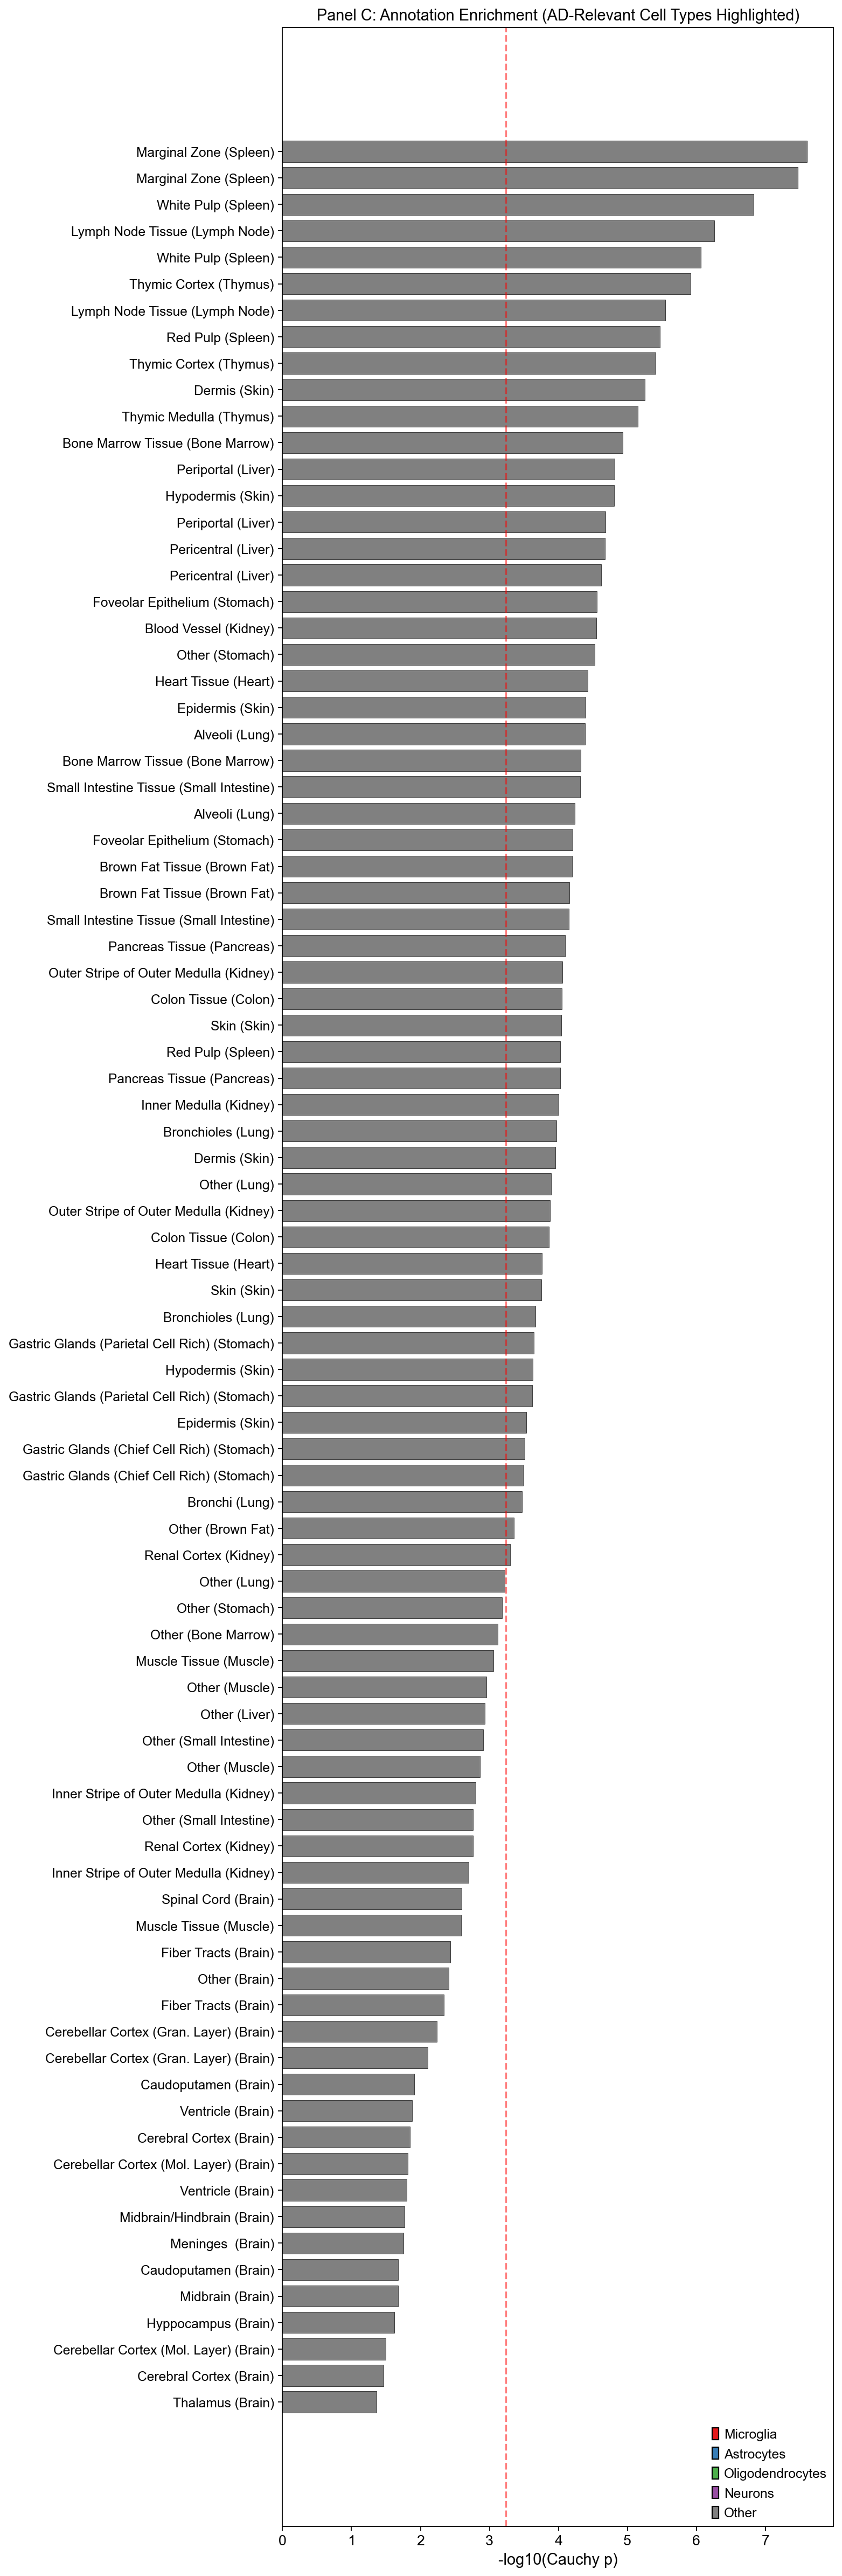

In [7]:
# Plot: bar chart of all annotations colored by AD relevance
# Sort by significance
plot_df = cauchy_all.copy()
plot_df = plot_df.sort_values('logp_cauchy', ascending=True)
plot_df['label'] = plot_df['annotation'] + ' (' + plot_df['organ'] + ')'

# Color by AD relevance
color_map = {'Microglia': '#e41a1c', 'Astrocytes': '#377eb8', 'Oligodendrocytes': '#4daf4a',
             'Neurons': '#984ea3', 'Other': 'grey'}
plot_df['color'] = plot_df['ad_celltype'].map(color_map)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)))
bars = ax.barh(range(len(plot_df)), plot_df['logp_cauchy'].values,
               color=plot_df['color'].values, edgecolor='k', linewidth=0.3)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'].values, fontsize=TICK_FS - 1)
ax.set_xlabel('-log10(Cauchy p)', fontsize=LABEL_FS)
ax.set_title('Panel C: Annotation Enrichment (AD-Relevant Cell Types Highlighted)', fontsize=TITLE_FS)

# Bonferroni threshold
bonf = -np.log10(0.05 / len(plot_df)) if len(plot_df) > 0 else 1.3
ax.axvline(bonf, color='red', linestyle='--', alpha=0.5, label=f'Bonferroni threshold')

# Legend for cell type colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[ct], edgecolor='k', label=ct)
                   for ct in ['Microglia', 'Astrocytes', 'Oligodendrocytes', 'Neurons', 'Other']]
ax.legend(handles=legend_elements, fontsize=LEGEND_FS, loc='lower right')
ax.tick_params(axis='x', labelsize=TICK_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S07C_ad_celltypes_enrichment')